# Compute UMAPs outside of model training pipeline

Extract the key UMAP functions from the OOP framework so that I can compute for any data.

In [2]:
import os
from os.path import join
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import torch
import polars as pl
import umap.umap_ as umap
import seaborn as sns
from adjustText import adjust_text
from cytoself.analysis.analysis_opencell import AnalysisOpenCell
from cytoself.datamanager.opencell import DataManagerOpenCell
from cytoself.trainer.cytoselflite_trainer import CytoselfFullTrainer
from cytoself.trainer.utils.plot_history import plot_history_cytoself
from cytoself.analysis.utils.cluster_score import calculate_cluster_centrosize

## 1. Loading trained model

In [3]:
# Updated for new trained model: varchamp_080125_clean_data
datapath = '../data/interim/3_model_input/2025_07_B78-1112-1314-1516_clean'
outputpath = "../models/varchamp_080125_clean_data"
model_nm = "model_43.pt"
data_ch = ['pro', 'nuc']
device="cuda:0"
model_path = f"{outputpath}/{model_nm}"

In [4]:
# NOTE: Embedding extraction is now handled by 5_get_embeddings.py script
# Run the script first before using this notebook:
# python ../scripts/5_get_embeddings.py \
#     --datapath "../inputs/1_model_input/2025_07_B78-1112-1314-1516_clean" \
#     --model_path "../outputs/trained_models/varchamp_080125_clean_data/model_43.pt" \
#     --outputpath "../outputs/trained_models/varchamp_080125_clean_data"

# Original embedding extraction code (commented out - now handled by script):
# datamanager = DataManagerOpenCell(datapath, data_ch, fov_col=None)
# datamanager.const_dataloader(batch_size=32, label_name_position=1)

# model_args = {
#     "input_shape": (2, 100, 100),
#     "emb_shapes": ((25, 25), (4, 4)),
#     "output_shape": (2, 100, 100),
#     "fc_output_idx": [2],
#     "vq_args": {"num_embeddings": 512, "embedding_dim": 64},
#     "num_class": len(datamanager.unique_labels),
#     "fc_input_type": "vqvec",
# }
# train_args = {
#     "lr": 0.0004,
#     "max_epoch": 100,
#     "reducelr_patience": 4,
#     "reducelr_increment": 0.1,
#     "earlystop_patience": 12,
# }

# trainer = CytoselfFullTrainer(train_args, homepath=outputpath, model_args=model_args)
# trainer.load_model(model_path)

# # infer embeddings
# test_embeddings = trainer.infer_embeddings(datamanager.DataLoader)

# if isinstance(test_embeddings, tuple) and len(test_embeddings) > 1:
#     test_embeddings = test_embeddings[0]

# savepath_embeddings = trainer.savepath_dict["embeddings"]
# np.save(join(savepath_embeddings, 'embeddings_testdata.npy'), test_embeddings)

# # infer embeddings for training data 
# train_embeddings = trainer.infer_embeddings(datamanager.train_loader)
# if isinstance(train_embeddings, tuple) and len(train_embeddings) > 1:
#     train_embeddings = train_embeddings[0]

# savepath_embeddings = trainer.savepath_dict["embeddings"]
# np.save(join(savepath_embeddings, 'embeddings_traindata.npy'), train_embeddings)

# # infer embeddings for training data 
# valid_embeddings = trainer.infer_embeddings(datamanager.val_loader)
# if isinstance(valid_embeddings, tuple) and len(valid_embeddings) > 1:
#     valid_embeddings = valid_embeddings[0]

# savepath_embeddings = trainer.savepath_dict["embeddings"]
# np.save(join(savepath_embeddings, 'embeddings_valdata.npy'), valid_embeddings)


# # save labels by data
# train_labels = datamanager.train_loader.dataset.label
# np.save(join(savepath_embeddings, 'labels_traindata.npy'), train_labels)

# val_labels = datamanager.val_loader.dataset.label
# np.save(join(savepath_embeddings, 'labels_valdata.npy'), val_labels)

# test_labels = datamanager.test_loader.dataset.label
# np.save(join(savepath_embeddings, 'labels_testdata.npy'), test_labels)

# 2. Plot UMAPs

In [5]:
# WORKAROUND for numpy loading issues in Jupyter
# If you get numpy errors, try restarting kernel or use alternative loading method

import sys
from os.path import join

# Updated paths for new trained model
umap_path = "../data/interim/4_analyses/umap_data"
print("Loading embedding files...")
print(f"Loading from: {outputpath}/embeddings/")

try:
    # Alternative loading method with explicit error handling
    def safe_load_npy(filepath, allow_pickle=False):
        """Safe numpy loading with better error handling"""
        try:
            return np.load(filepath, allow_pickle=allow_pickle)
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            # Try alternative method
            import pickle
            with open(filepath, 'rb') as f:
                return pickle.load(f)
    
    # Load embeddings
    trainer_embeddings = safe_load_npy(join(f"{outputpath}/embeddings", 'embeddings_traindata.npy'))
    val_embeddings = safe_load_npy(join(f"{outputpath}/embeddings", 'embeddings_valdata.npy'))
    test_embeddings = safe_load_npy(join(f"{outputpath}/embeddings", 'embeddings_testdata.npy'))

    # Load labels
    train_labels = safe_load_npy(join(f"{outputpath}/embeddings", 'labels_traindata.npy'), allow_pickle=True)
    val_labels = safe_load_npy(join(f"{outputpath}/embeddings", 'labels_valdata.npy'), allow_pickle=True)
    test_labels = safe_load_npy(join(f"{outputpath}/embeddings", 'labels_testdata.npy'), allow_pickle=True)
    
    print("✅ All files loaded successfully!")
    print(f"Shapes - Test: {test_embeddings.shape}, Train: {trainer_embeddings.shape}, Val: {val_embeddings.shape}")
    
except Exception as e:
    print(f"❌ Loading failed: {e}")
    print("Try restarting the kernel (Kernel -> Restart) and run this cell again")
    print("Or run the test script: python ../scripts/test_load_embeddings.py")

Loading embedding files...
Loading from: ../models/varchamp_080125_clean_data/embeddings/
✅ All files loaded successfully!
Shapes - Test: (186841, 64, 4, 4), Train: (1868404, 64, 4, 4), Val: (223297, 64, 4, 4)


In [6]:
umap_test_df = pl.read_parquet(join(umap_path, "umap_comps_testdata.parquet"))
umap_test_df = umap_test_df.with_columns(
    pl.col("Metadata_CellID").str.extract(r"(B\d+)A", 1).alias("batch"),
    pl.col("Metadata_CellID").str.slice(23,3).alias("well_position"),
    pl.col("Metadata_Protein").str.split(by="-").list.get(0).alias("Gene"),
    (pl.when(pl.col("Metadata_Protein").str.contains("-"))
    .then(pl.lit("Allele"))
    .otherwise(pl.lit("Reference"))).alias("Allele_type")
)
umap_test_df.head()

Metadata_Protein,Metadata_CellID,Comp1,Comp2,batch,well_position,Gene,Allele_type
str,str,f32,f32,str,str,str,str
"""G6PD-Arg198Pro""","""2025_01_28_B14A7A8P2_T4_A09_76…",-0.700614,-2.449975,"""B14""","""_A0""","""G6PD""","""Allele"""
"""SLIRP""","""2025-03-17_B15A1A2_P1T1_G17_14…",8.384151,3.846976,"""B15""","""_G1""","""SLIRP""","""Reference"""
"""PHYH-Arg275Trp""","""2025-03-17_B15A1A2_P1T1_H05_15…",2.679779,15.67526,"""B15""","""_H0""","""PHYH""","""Allele"""
"""KCTD1-Ala30Glu""","""2024_01_17_B7A1R1_P2T3_P17_339…",0.233774,7.769888,"""B7""","""P17""","""KCTD1""","""Allele"""
"""CCM2-Gly162Glu""","""2025_01_27_B13A7A8P2_T1_B03_23…",-3.669336,-2.049202,"""B13""","""_B0""","""CCM2""","""Allele"""


### 2.1 Metadata_Batch

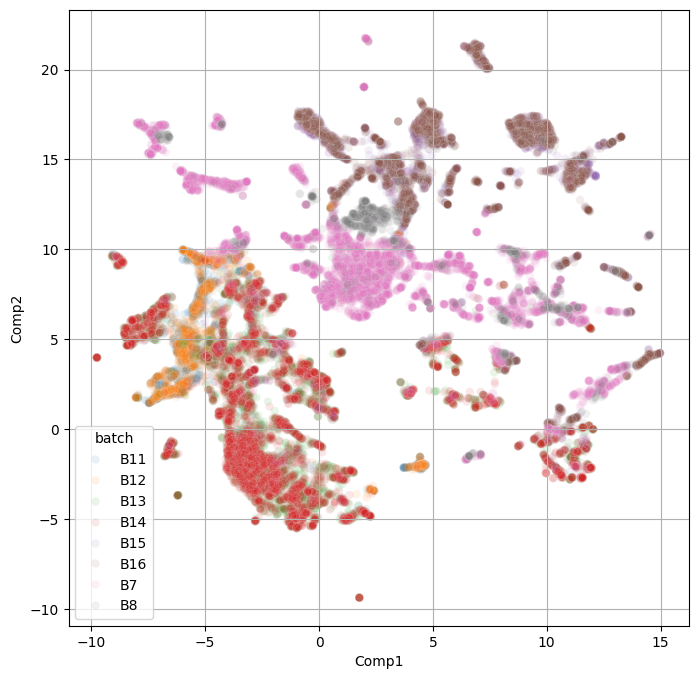

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.scatterplot(
    data=umap_test_df.sample(fraction=.2, shuffle=True).sort(by="batch").to_pandas(), 
    x="Comp1", y="Comp2", hue="batch", 
    alpha=.1, ax=ax
)
ax.grid(True)

In [ ]:
# Compute centroid of each WT
wt_centroid = umap_test_df.filter(~pl.col("Metadata_Protein").str.contains("-")).group_by("Metadata_Protein").agg([
    pl.col("Comp1").median().alias("Comp1"),
    pl.col("Comp2").median().alias("Comp2"),
])

plt.figure(figsize=(10, 10))
sns.kdeplot(data=umap_test_df.to_pandas(), x="Comp1", y="Comp2", fill=True, cmap="Greys", alpha=0.8, thresh=0, levels=100)

# Overlay the text labels
texts = []
for i, row in wt_centroid.to_pandas().iterrows():
    texts.append(plt.text(row["Comp1"], row["Comp2"], row["Metadata_Protein"], 
                          fontsize=8, fontweight='bold', color='black'))

# Adjust text to avoid overlaps
adjust_text(texts, expand_points=(2, 2), arrowprops=dict(arrowstyle='-', color='red', lw=0.5, shrinkA=1.))
plt.title("Centroids of WT alleles")
plt.savefig(f"{outputpath}/analysis/umap_figures/umap_wt_centroid_density.svg", format='svg')

### 2.3 Subcell loc annotations

In [8]:
subcell_loc = pl.read_csv("../data/external/subcell_loc/final_merged_subcellular_data.csv")
subcell_loc

ensg_id,HPA_Gene name,HPA_Reliability,HPA_Main location,HPA_Additional location,HPA_Extracellular location,HPA_Enhanced,HPA_Supported,HPA_Approved,HPA_Uncertain,HPA_Single-cell variation intensity,HPA_Single-cell variation spatial,HPA_Cell cycle dependency,HPA_GO id,OpenCell_target_name,OpenCell_annotations_grade_3,OpenCell_annotations_grade_2,OpenCell_annotations_grade_1,UniProt_Entry,UniProt_Entry Name,UniProt_Gene Names,UniProt_Protein names,UniProt_Organism,UniProt_Subcellular location [CC],UniProt_Gene Ontology (cellular component),UniProt_Gene Ontology IDs,UniProt_Ensembl,official_gene_name
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""ENSG00000000003""","""TSPAN6""","""Approved""","""Cell Junctions;Cytosol""","""Nucleoli fibrillar center""",null,null,null,"""Cell Junctions;Cytosol;Nucleol…",null,"""Cytosol""",null,null,"""Cell Junctions (GO:0030054);Cy…",null,null,null,null,"""O43657""","""TSN6_HUMAN""","""TSPAN6 TM4SF6 UNQ767/PRO1560""","""Tetraspanin-6 (Tspan-6) (A15 h…","""Homo sapiens (Human)""","""SUBCELLULAR LOCATION: Membrane…","""extracellular exosome [GO:0070…","""GO:0005886; GO:0039532; GO:004…","""ENST00000373020.9;""","""TSPAN6"""
"""ENSG00000000003""","""TSPAN6""","""Approved""","""Cell Junctions;Cytosol""","""Nucleoli fibrillar center""",null,null,null,"""Cell Junctions;Cytosol;Nucleol…",null,"""Cytosol""",null,null,"""Cell Junctions (GO:0030054);Cy…",null,null,null,null,"""A0A087WYV6""","""A0A087WYV6_HUMAN""","""TSPAN6""","""Tetraspanin-6""","""Homo sapiens (Human)""","""SUBCELLULAR LOCATION: Membrane…","""membrane [GO:0016020]""","""GO:0016020""","""ENST00000612152.4;""","""TSPAN6"""
"""ENSG00000000457""","""SCYL3""","""Supported""","""Cytosol;Golgi apparatus""",null,null,null,"""Cytosol;Golgi apparatus""",null,null,null,null,null,"""Cytosol (GO:0005829);Golgi app…",null,null,null,null,"""Q8IZE3""","""PACE1_HUMAN""","""SCYL3 PACE1""","""Protein-associating with the c…","""Homo sapiens (Human)""","""SUBCELLULAR LOCATION: Cytoplas…","""cytoplasm [GO:0005737]; cytoso…","""GO:0000139; GO:0005524; GO:000…","""ENST00000367770.5 [Q8IZE3-1];E…","""SCYL3"""
"""ENSG00000000457""","""SCYL3""","""Supported""","""Cytosol;Golgi apparatus""",null,null,null,"""Cytosol;Golgi apparatus""",null,null,null,null,null,"""Cytosol (GO:0005829);Golgi app…",null,null,null,null,"""X6RHX1""","""X6RHX1_HUMAN""","""SCYL3""","""Protein-associating with the c…","""Homo sapiens (Human)""","""SUBCELLULAR LOCATION: Cell pro…","""cytosol [GO:0005829]; endoplas…","""GO:0004672; GO:0005524; GO:000…","""ENST00000423670.1;""","""SCYL3"""
"""ENSG00000000460""","""C1orf112""","""Supported""","""Nucleoplasm""","""Nucleoli""",null,null,"""Nucleoli;Nucleoplasm""",null,null,null,null,null,"""Nucleoli (GO:0005730);Nucleopl…",null,null,null,null,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000291237""","""SOD2""","""Supported""","""Mitochondria""",null,null,null,"""Mitochondria""",null,null,null,null,null,"""Mitochondria (GO:0005739)""",null,null,null,null,"""F5H3C5""","""F5H3C5_HUMAN""","""SOD2""","""Superoxide dismutase (EC 1.15.…","""Homo sapiens (Human)""","""SUBCELLULAR LOCATION: Mitochon…","""mitochondrial matrix [GO:00057…","""GO:0004784; GO:0005759; GO:004…","""ENST00000537657.5;""","""SOD2"""
"""ENSG00000291237""","""SOD2""","""Supported""","""Mitochondria""",null,null,null,"""Mitochondria""",null,null,null,null,null,"""Mitochondria (GO:0005739)""",null,null,null,null,"""F5GXZ9""","""F5GXZ9_HUMAN""","""SOD2""","""Superoxide dismutase [Mn], mit…","""Homo sapiens (Human)""","""SUBCELLULAR LOCATION: Mitochon…","""mitochondrial matrix [GO:00057…","""GO:0004784; GO:0005759; GO:004…","""ENST00000546260.5;""","""SOD2"""
"""ENSG00000291237""","""SOD2""","""Supported""","""Mitochondria""",null,null,null,"""Mitochondria""",null,null,null,null,null,"""Mitochondria (GO:0005739)""",null,null,null,null,"""G8JLJ2""","""G8

In [9]:
# umap_test_df.unique("Gene")

In [10]:
umap_test_plot_df = umap_test_df.join(
    subcell_loc,
    left_on="Metadata_Protein",
    right_on="HPA_Gene name",
    how="left"
).rename(
    {
        "HPA_Main location": "Metadata_hpa_main_loc",
        "HPA_Additional location": "Metadata_hpa_additional_loc",
        "Comp1": "UMAP1",
        "Comp2": "UMAP2"
    }
)

umap_test_plot_df

Metadata_Protein,Metadata_CellID,UMAP1,UMAP2,batch,well_position,Gene,Allele_type,ensg_id,HPA_Reliability,Metadata_hpa_main_loc,Metadata_hpa_additional_loc,HPA_Extracellular location,HPA_Enhanced,HPA_Supported,HPA_Approved,HPA_Uncertain,HPA_Single-cell variation intensity,HPA_Single-cell variation spatial,HPA_Cell cycle dependency,HPA_GO id,OpenCell_target_name,OpenCell_annotations_grade_3,OpenCell_annotations_grade_2,OpenCell_annotations_grade_1,UniProt_Entry,UniProt_Entry Name,UniProt_Gene Names,UniProt_Protein names,UniProt_Organism,UniProt_Subcellular location [CC],UniProt_Gene Ontology (cellular component),UniProt_Gene Ontology IDs,UniProt_Ensembl,official_gene_name
str,str,f32,f32,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""G6PD-Arg198Pro""","""2025_01_28_B14A7A8P2_T4_A09_76…",-0.700614,-2.449975,"""B14""","""_A0""","""G6PD""","""Allele""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""SLIRP""","""2025-03-17_B15A1A2_P1T1_G17_14…",8.384151,3.846976,"""B15""","""_G1""","""SLIRP""","""Reference""","""ENSG00000119705""","""Supported""","""Mitochondria""",null,null,null,"""Mitochondria""",null,null,"""Mitochondria""",null,null,"""Mitochondria (GO:0005739)""",null,null,null,null,"""Q9GZT3""","""SLIRP_HUMAN""","""SLIRP C14orf156 DC23 DC50 PD04…","""SRA stem-loop-interacting RNA-…","""Homo sapiens (Human)""","""SUBCELLULAR LOCATION: Mitochon…","""acrosomal vesicle [GO:0001669]…","""GO:0000961; GO:0001669; GO:000…","""ENST00000238688.9 [Q9GZT3-2];E…","""SLIRP"""
"""SLIRP""","""2025-03-17_B15A1A2_P1T1_G17_14…",8.384151,3.846976,"""B15""","""_G1""","""SLIRP""","""Reference""","""ENSG00000119705""","""Supported""","""Mitochondria""",null,null,null,"""Mitochondria""",null,null,"""Mitochondria""",null,null,"""Mitochondria (GO:0005739)""",null,null,null,null,"""H0YJ40""","""H0YJ40_HUMAN""","""SLIRP""","""SRA stem-loop-interacting RNA-…","""Homo sapiens (Human)""","""SUBCELLULAR LOCATION: Mitochon…","""mitochondrion [GO:0005739]""","""GO:0003723; GO:0005739""","""ENST00000556831.5;""","""SLIRP"""
"""SLIRP""","""2025-03-17_B15A1A2_P1T1_G17_14…",8.384151,3.846976,"""B15""","""_G1""","""SLIRP""","""Reference""","""ENSG00000119705""","""Supported""","""Mitochondria""",null,null,null,"""Mitochondria""",null,null,"""Mitochondria""",null,null,"""Mitochondria (GO:0005739)""",null,null,null,null,"""G3V4X6""","""G3V4X6_HUMAN""","""SLIRP""","""SRA stem-loop-interacting RNA-…","""Homo sapiens (Human)""","""SUBCELLULAR LOCATION: Mitochon…","""mitochondrion [GO:0005739]""","""GO:0003723; GO:0005739""","""ENST00000557623.5;""","""SLIRP"""
"""SLIRP""","""2025-03-17_B15A1A2_P1T1_G17_14…",8.384151,3.846976,"""B15""","""_G1""","""SLIRP""","""Reference""","""ENSG00000119705""","""Supported""","""Mitochondria""",null,null,null,"""Mitochondria""",null,null,"""Mitochondria""",null,null,"""Mitochondria (GO:0005739)""",null,null,null,null,"""A0A087WUN7""","""A0A087WUN7_HUMAN""","""SLIRP""","""SRA stem-loop-interacting RNA-…","""Homo sapiens (Human)""","""SUBCELLULAR LOCATION: Mitochon…","""mitochondrion [GO:0005739]""","""GO:0003723; GO:0005739""","""ENST00000613856.4;""","""SLIRP"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ALK-Arg1275Gln""","""2025_01_27_B13A7A8P2_T4_I10_18…",5.236937,4.624056,"""B13""","""_I1""","""ALK""","""Allele""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""GFAP-Arg88Cys""","""2025-03-17_B16A1A2_P1T1_M17_27…",6.806461,21.383579,"""B16""","""_M1""","""GFAP""","""Allele""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""CCM2-Pro271Thr""","""2025_01_28_B14A7A8P2_T4_H15_16…",-3.919231,-0.380832,"""B14""","""_H1""","""CCM2""","""Allele""",null,null,null,null,nu

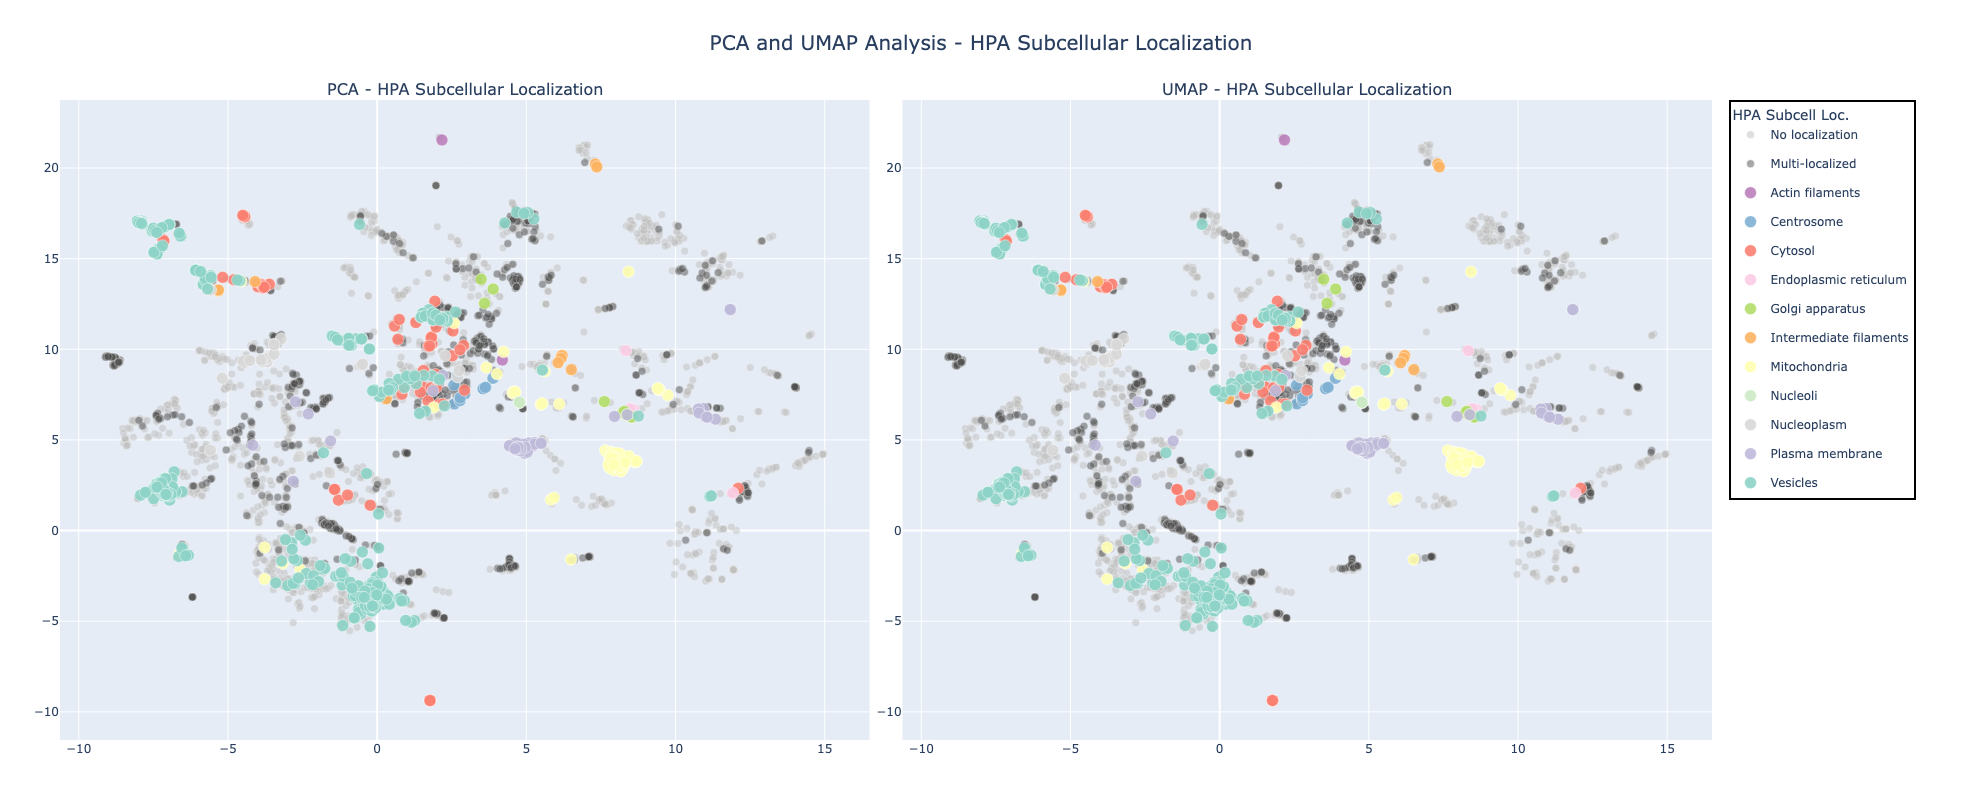

In [17]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def create_localization_only_plots(df):
   """Create PCA and UMAP plots colored only by localization"""
   
   df = df.copy()
   df['localization_category'] = df.apply(lambda row: 
       'No localization' if (pd.isna(row['Metadata_hpa_main_loc']) or row['Metadata_hpa_main_loc'] == 'None') else
       'Multi-localized' if (';' in str(row['Metadata_hpa_main_loc']) or 
                            (not pd.isna(row['Metadata_hpa_additional_loc']) and 
                             row['Metadata_hpa_additional_loc'] != 'None')) else
       str(row['Metadata_hpa_main_loc']), axis=1
   )
   
   # Create subplots with reduced spacing
   fig = make_subplots(
       rows=1, cols=2,
       subplot_titles=('PCA - HPA Subcellular Localization', 'UMAP - HPA Subcellular Localization'),
       horizontal_spacing=0.02
   )
   
   # Color schemes
   unique_locs = [loc for loc in df['localization_category'].unique() 
                  if loc not in ['No localization', 'Multi-localized']]
   colors = px.colors.qualitative.Set3 + px.colors.qualitative.Pastel + px.colors.qualitative.Set1
   loc_colors = {loc: colors[i % len(colors)] for i, loc in enumerate(unique_locs)}
   loc_colors['No localization'] = '#C0C0C0'
   loc_colors['Multi-localized'] = '#505050'
   
   # Plot configurations
   plots_config = [
       ('UMAP1', 'UMAP2', 1, 1),
       ('UMAP1', 'UMAP2', 1, 2)
   ]
   
   # Define plotting order: background categories first, then specific localizations
   background_categories = ['No localization', 'Multi-localized']
   specific_categories = [cat for cat in sorted(df['localization_category'].unique()) 
                        if cat not in background_categories]
   plot_order = background_categories + specific_categories
   
   for x_col, y_col, row, col in plots_config:
       for i, value in enumerate(plot_order):
           if value not in df['localization_category'].values:
               continue
               
           subset = df[df['localization_category'] == value]
           
           if len(subset) == 0:
               continue
           
           color = loc_colors.get(value, '#000000')
           # Make background categories less prominent but still visible
           if value in ['No localization', 'Multi-localized']:
               opacity = 0.5
               size = 8
           else:
               opacity = 0.9
               size = 12
           
           # Only show legend for first subplot to avoid duplicates
           show_legend = (col == 1)
           
           fig.add_trace(
               go.Scatter(
                   x=subset[x_col],
                   y=subset[y_col],
                   mode='markers',
                   name=str(value),
                   legendgroup=str(value),
                   showlegend=show_legend,
                   marker=dict(
                       color=color, 
                       size=size, 
                       opacity=opacity,
                       line=dict(width=0.5, color='white')
                   ),
                   customdata=np.column_stack((
                       subset.index,
                       subset['Metadata_CellID'],
                       subset['Metadata_hpa_main_loc'].fillna('None'),
                       subset['Metadata_hpa_additional_loc'].fillna('None'),
                   )),
                   hovertemplate='<b>%{customdata[0]}</b><br>' +
                                # f'{x_col}: %{{x:.3f}}<br>' +
                                # f'{y_col}: %{{y:.3f}}<br>' +
                                'CellID: %{customdata[1]}<br>' +
                                'Localization: %{customdata[2]}<br>' +
                                'Additional Localization: %{customdata[3]}<br>' +
                                '<extra></extra>'
               ),
               row=row, col=col
           )
   
   # Update subplot titles with larger font
   for i, annotation in enumerate(fig['layout']['annotations']):
       annotation['font'] = dict(size=16)
   
   fig.update_layout(
       title=dict(
           text='PCA and UMAP Analysis - HPA Subcellular Localization',
           font=dict(size=20),
           x=0.5
       ),
       height=800,
       width=1600,
       legend=dict(
           title=dict(text='HPA Subcell Loc.', font=dict(size=14)),
           font=dict(size=12),
           yanchor="top",
           y=1.0,
           xanchor="left",
           x=1.01,
           bgcolor="rgba(255,255,255,0.9)",
           bordercolor="Black",
           borderwidth=2
       ),
       margin=dict(l=60, r=250, t=100, b=60),
       showlegend=True
   )
   
   # Update axis labels
   fig.update_xaxes(title_font=dict(size=14), tickfont=dict(size=12))
   fig.update_yaxes(title_font=dict(size=14), tickfont=dict(size=12))
   
   return fig

# Usage
dashboard = create_localization_only_plots(
    df=pl.concat([
        umap_test_plot_df.filter(pl.col("Metadata_Protein")=="AGXT"),
        umap_test_plot_df.filter(pl.col("Metadata_Protein")!="AGXT").sample(fraction=0.01),
    ]).to_pandas().set_index("Metadata_Protein")
)
dashboard.show()

# Show summary statistics
# print("\nDataset Summary:")
# print(f"Total genes: {len(data_results)}")
# df_indexed = data_results.set_index("Metadata_gene_allele")
# df_indexed['localization_category'] = df_indexed.apply(lambda row: 
#    'No localization' if (pd.isna(row['Metadata_hpa_main_loc']) or row['Metadata_hpa_main_loc'] == 'None') else
#    'Multi-localized' if (';' in str(row['Metadata_hpa_main_loc']) or 
#                         (not pd.isna(row['Metadata_hpa_additional_loc']) and 
#                          row['Metadata_hpa_additional_loc'] != 'None')) else
#    str(row['Metadata_hpa_main_loc']), axis=1
# )
# print(f"Localization patterns:")
# print(df_indexed['localization_category'].value_counts())

In [ ]:
umap_test_df.drop_nulls(subset="HPA_Main location").filter(
    pl.col("HPA_Reliability")=="Approved",
    pl.col("HPA_Additional location").is_null()
).unique("HPA_Main location")

In [ ]:
fig, (ax, ax1) = plt.subplots(1, 2, figsize=(18, 9))
sns.scatterplot(
    data=umap_test_df.drop_nulls(subset="HPA_Main location").filter(
        pl.col("HPA_Reliability")=="Approved",
        pl.col("HPA_Additional location").is_null()
    ).to_pandas(), 
    x="Comp1", y="Comp2", hue="HPA_Main location", 
    alpha=.3, ax=ax
)
ax.grid(True)
ax.legend(bbox_to_anchor*)

# Compute centroid of each WT
wt_centroid = umap_test_df.drop_nulls(subset="HPA_Main location").filter(
        pl.col("HPA_Reliability")=="Approved",
        pl.col("HPA_Additional location").is_null()
    ).group_by("HPA_Main location").agg([
    pl.col("Comp1").median().alias("Comp1"),
    pl.col("Comp2").median().alias("Comp2"),
])
sns.kdeplot(
    data=umap_test_df.drop_nulls(subset="HPA_Main location").filter(
        pl.col("HPA_Reliability")=="Approved",
        pl.col("HPA_Additional location").is_null()
    ).to_pandas(), ax=ax1,
    x="Comp1", y="Comp2", fill=True, cmap="Greys", alpha=0.8, thresh=0, levels=100
)
# Overlay the text labels
texts = []
for i, row in wt_centroid.to_pandas().iterrows():
    texts.append(ax1.text(row["Comp1"], row["Comp2"], row["HPA_Main location"], 
                          fontsize=8, fontweight='bold', color='black'))

# Adjust text to avoid overlaps
adjust_text(texts, expand_points=(2, 2), arrowprops=dict(arrowstyle='-', color='red', lw=0.5, shrinkA=1.))
ax1.set_title("Centroids of Subcellular Localization")
# plt.savefig(f"{outputpath}/analysis/umap_figures/umap_wt_centroid_density.svg", format='svg')

In [ ]:
umap_test_df.drop_nulls(subset="HPA_Main location").filter(
    pl.col("HPA_Reliability")=="Approved",
    pl.col("HPA_Additional location").is_null()
)

In [21]:
def get_custom_colormap(num_colors, first_color='#D3D3D3'):
    # Generate a colormap with the specified number of colors
    # cmap = plt.get_cmap('tab10', num_colors)
    # Generate a color palette with 25 distinct colors using the 'cubehelix' system
    palette = sns.color_palette("husl", num_colors)
    colors = palette # [first_color]
    # colors += [c for c in palette if c != first_color]
    # Replace the first color with light grey
    return colors

In [22]:
def plot_gene_umap(umap_df, gene):
    fig, ax = plt.subplots(1, 1, figsize=(18, 18))
    ax.grid(True)

    umap_df = umap_df.with_columns(
        pl.when(pl.col("Metadata_Protein").str.contains(gene))
        .then(pl.col("Metadata_Protein"))
        .otherwise(pl.lit("000")).alias(f"{gene}_Variant")
    ).sort(f"{gene}_Variant")
    
    sns.scatterplot(umap_df.filter(pl.col(f"{gene}_Variant") == "000").to_pandas(), x="Comp1", y="Comp2", color="grey", alpha=.1, ax=ax)
    colors = get_custom_colormap(len(umap_df.filter(pl.col(f"{gene}_Variant") != "000").select(f"{gene}_Variant").unique().to_numpy()))
    sns.scatterplot(umap_df.filter(pl.col(f"{gene}_Variant") != "000").to_pandas(), x="Comp1", y="Comp2", hue=f"{gene}_Variant", style="batch", palette=colors, ax=ax, s=70, alpha=0.7)

    return umap_df.filter(pl.col(f"{gene}_Variant") != "000")

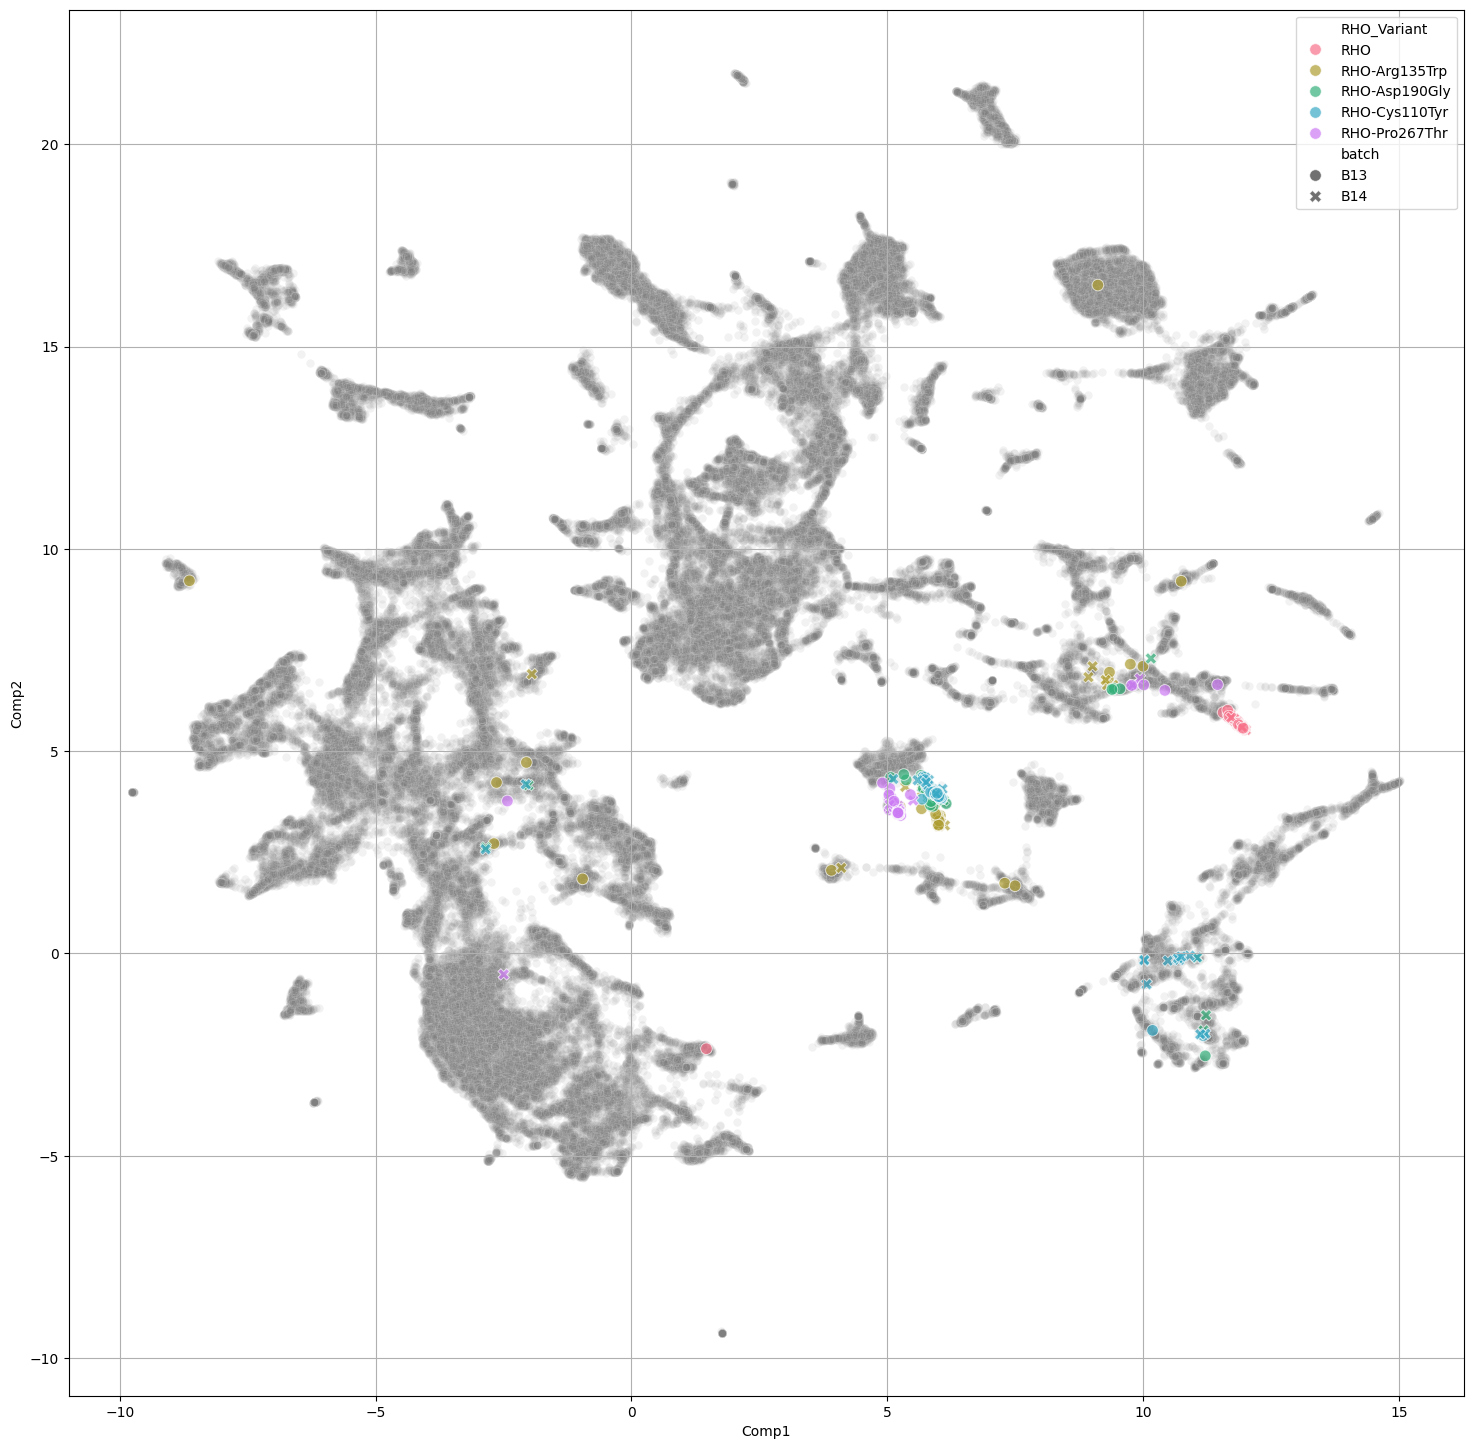

In [23]:
rho_umap_df = plot_gene_umap(umap_test_df, "RHO")

In [24]:
rho_umap_df_subset = rho_umap_df.filter(
    (pl.col("Comp2")>5) & (pl.col("Comp2")<10) & (pl.col("Comp1")>0)
)

rho_umap_df_subset_hits = rho_umap_df.filter(
    (pl.col("Comp2")>0) & (pl.col("Comp2")<5) & (pl.col("Comp1")>3) & (pl.col("Comp1")<8)
)

In [25]:
import matplotlib as mpl
def channel_to_cmap(channel):
    if channel == "pro":
        cmap = mpl.colors.LinearSegmentedColormap.from_list("green_cmap", ["#000","#65fe08"])
    elif channel == "nuc":
        cmap = mpl.colors.LinearSegmentedColormap.from_list("green_cmap", ["#000","#0000FF"])
    # elif channel == "Mito":
    #     cmap = mpl.colors.LinearSegmentedColormap.from_list("green_cmap", ["#000","#FF0000"]) 
    # elif channel == "AGP":
    #     cmap = mpl.colors.LinearSegmentedColormap.from_list("green_cmap", ["#000","#FFFF00"]) 
    else:
        cmap = "gray"
    return cmap


def viz_cell_crop(img_arr, cell_comp, max_intensity=.99, ax=None, axis_off=True):
    cmap = channel_to_cmap(cell_comp)
    if ax is None:
        plt.imshow(img_arr, vmin=0, vmax=np.percentile(img_arr, max_intensity*100), cmap=cmap)
        if axis_off:
            plt.axis('off')  # Turn off axis labels
        plt.show()
    else:
        ax.imshow(img_arr, vmin=0, vmax=np.percentile(img_arr, max_intensity*100), cmap=cmap)
        if axis_off:
            ax.axis('off')
        plot_label = f"s2n ratio:\n{np.percentile(img_arr, 99) / np.percentile(img_arr, 25):.3f}"
        ax.text(0.05, 0.95, plot_label, color='white', fontsize=9,
                verticalalignment='top', horizontalalignment='left', 
                transform=ax.transAxes,
                bbox=dict(facecolor='black', alpha=0.2, linewidth=1))

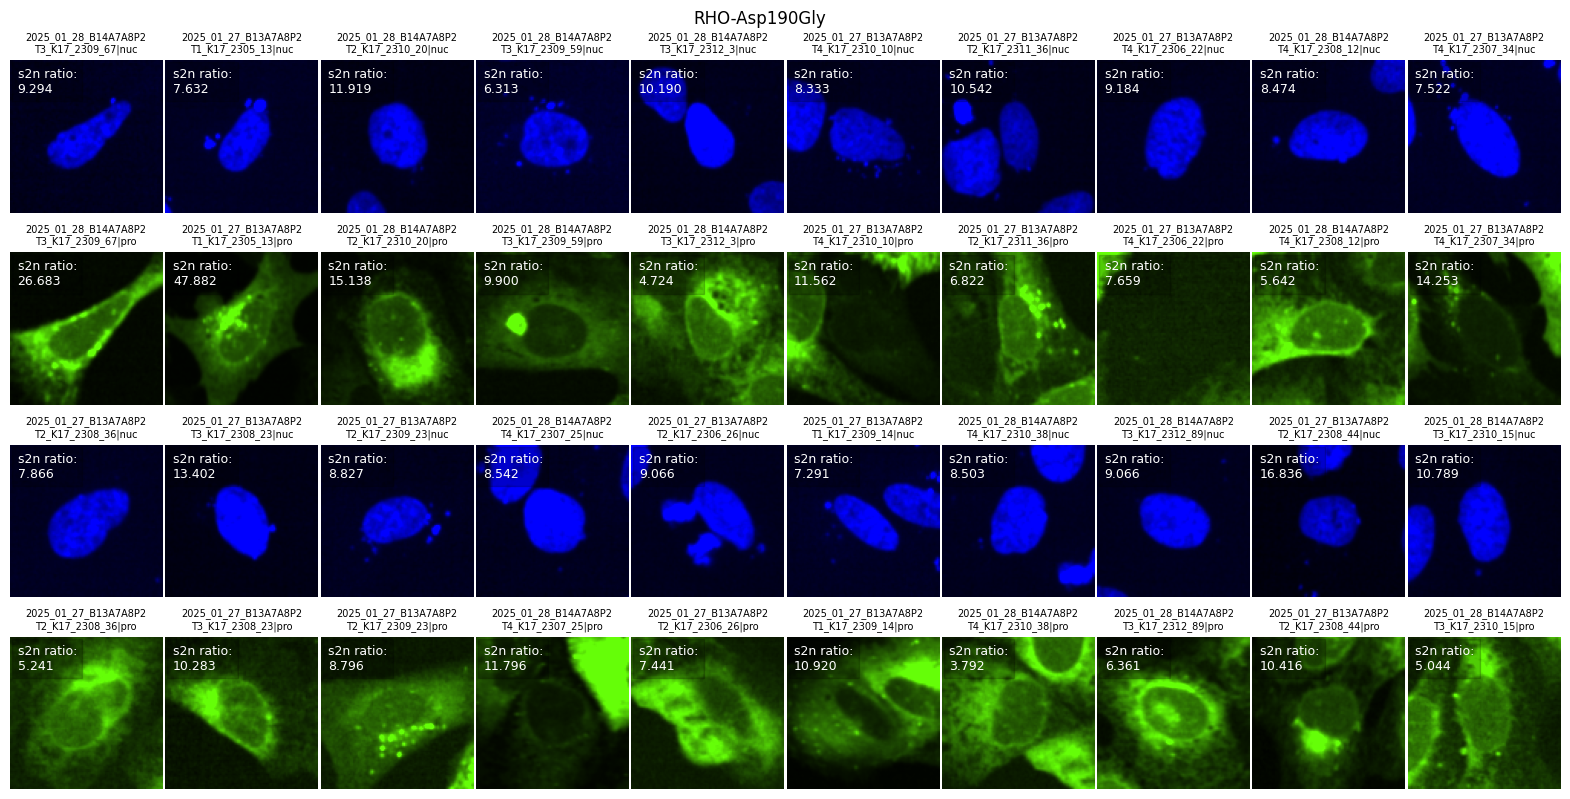

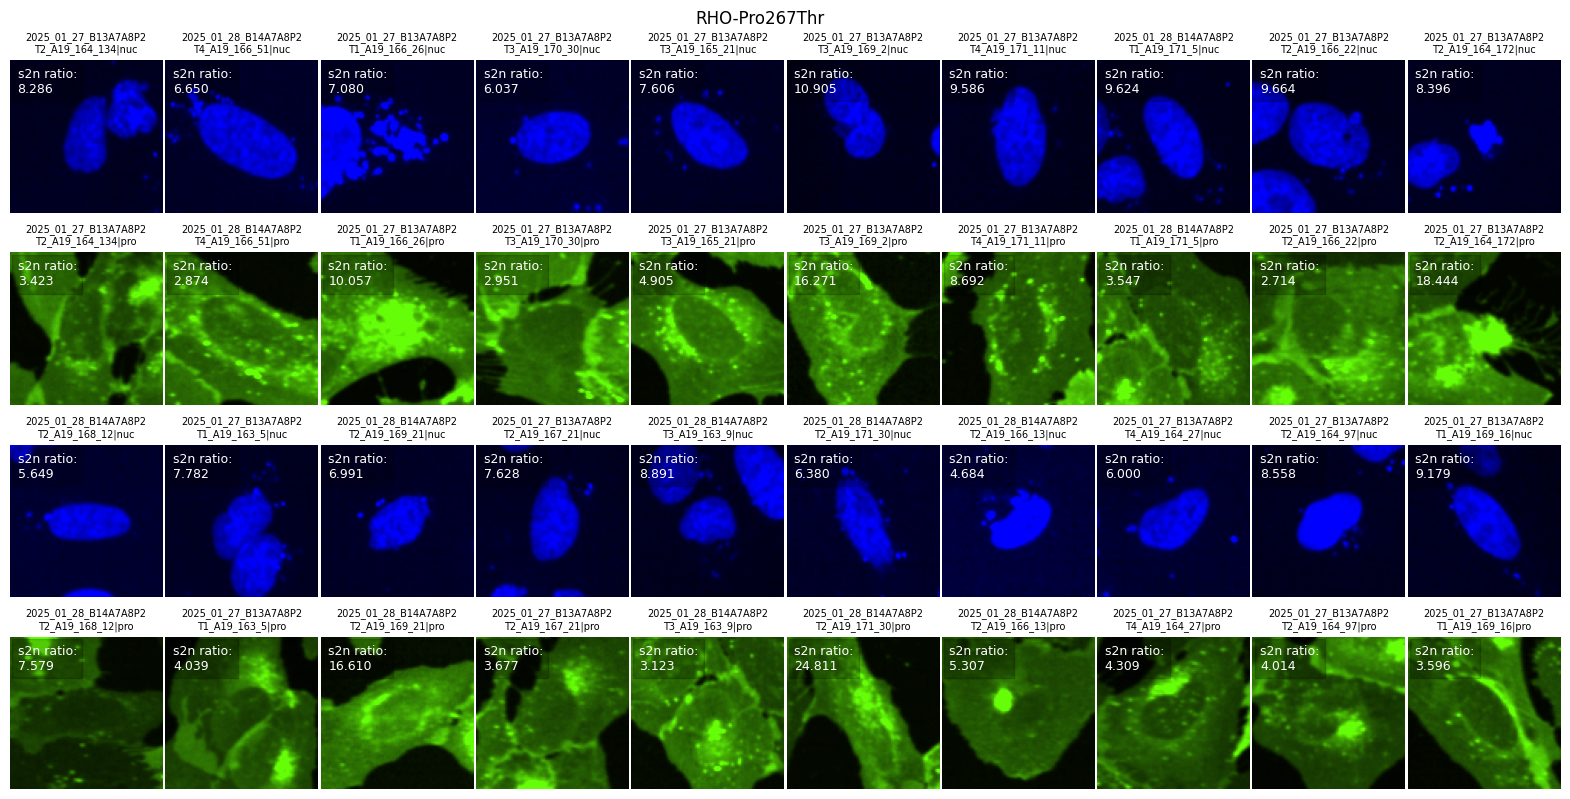

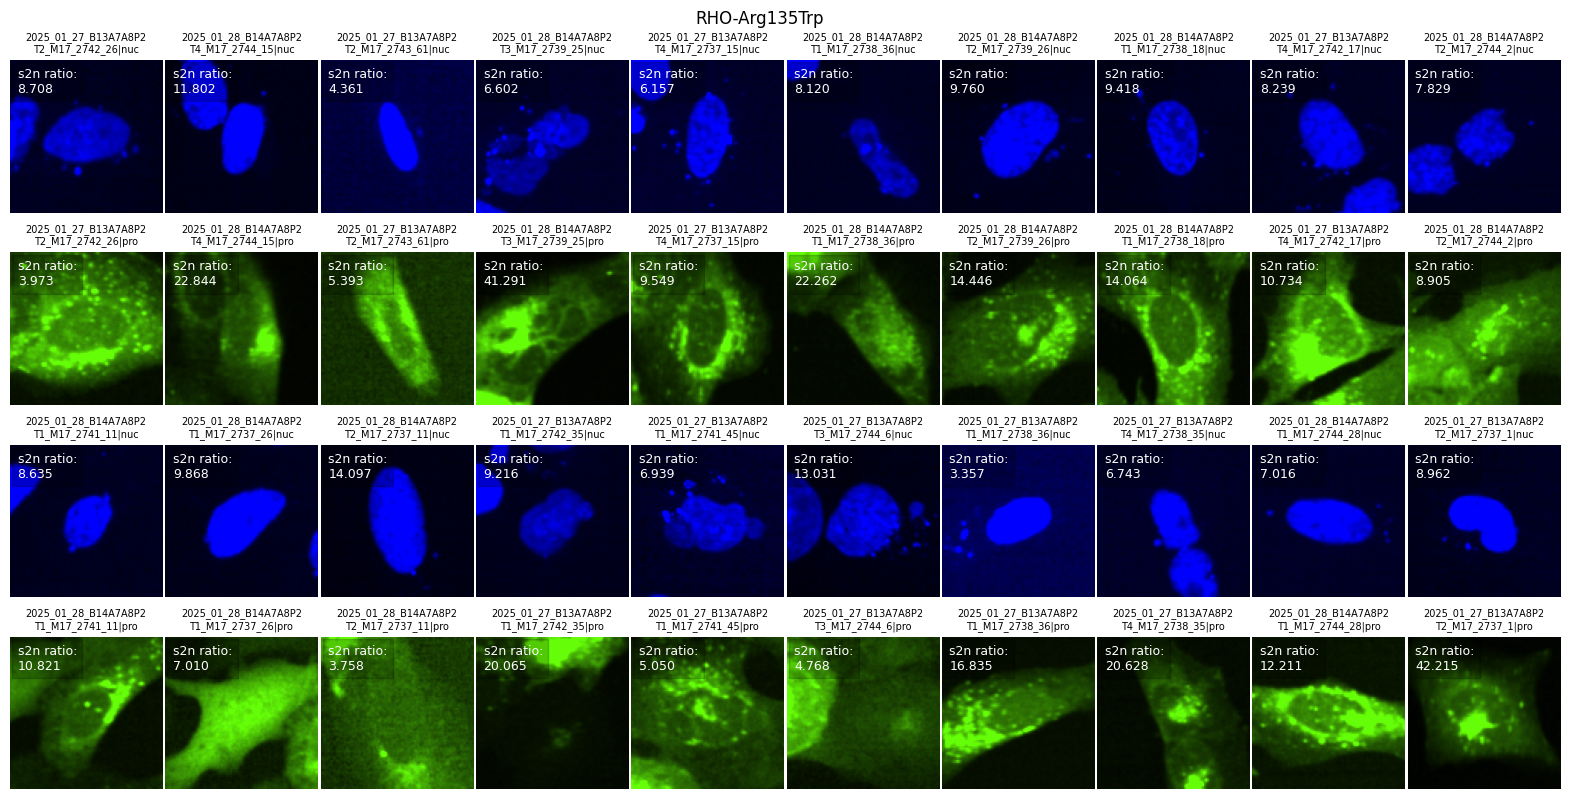

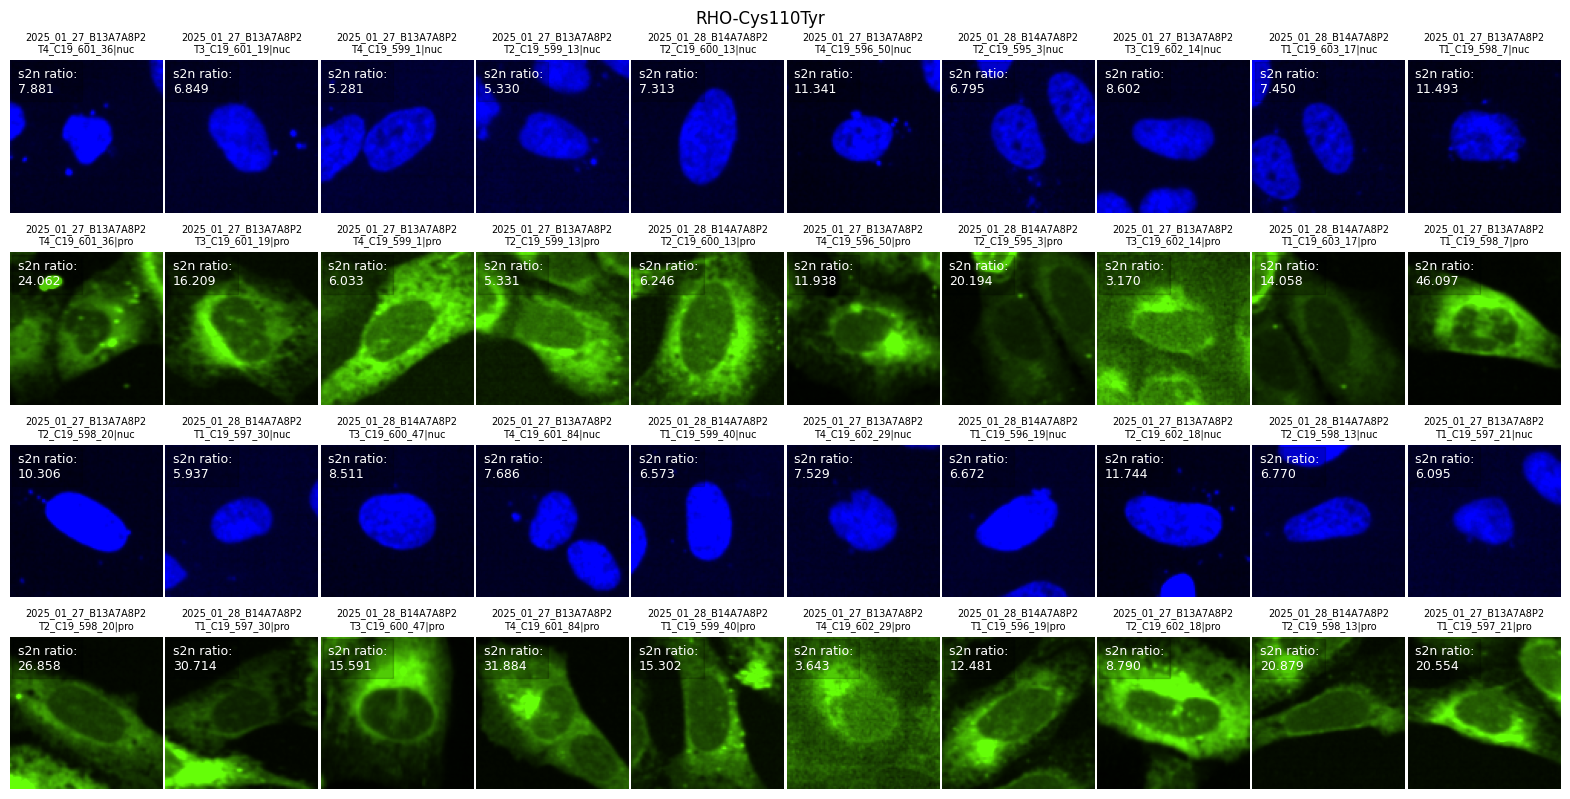

In [27]:
# Compare this to the example data structure
# Meta has #cells X 3 columns, each of three imaging npy have #cells X 100x100 pixels
# Need to find out if the pipeline will accept the concatenated data or if I need to split it & format like sample data in order to train the model. 

for gene_allele in rho_umap_df_subset_hits["Metadata_Protein"].unique():
    ex_meta = np.load(f"../data/interim/3_model_input/2025_07_B78-1112-1314-1516_clean/{gene_allele}_label.npy", allow_pickle=True)
    ex_nuc = np.load(f"../data/interim/3_model_input/2025_07_B78-1112-1314-1516_clean/{gene_allele}_nuc.npy", allow_pickle=True)
    ex_prot = np.load(f"../data/interim/3_model_input/2025_07_B78-1112-1314-1516_clean/{gene_allele}_pro.npy", allow_pickle=True)
    ex_meta = np.array([list(x) for x in ex_meta if x[1] in rho_umap_df_subset_hits["Metadata_CellID"].unique()])
    replace = not (len(ex_meta)>=20)
    random_cells = np.random.choice(np.arange(len(ex_meta)), 20, replace=replace)
    # break
    fig, axes = plt.subplots(4, 10, figsize=(20, 10))
    for idx, cell in enumerate(random_cells):
        if idx < 10:
            ## plot nuc
            viz_cell_crop(ex_nuc[cell,:,:], "nuc", ax=axes[idx // 10, idx % 10])
            viz_cell_crop(ex_prot[cell,:,:], "pro", ax=axes[idx // 10 + 1, idx % 10])
            axes[idx // 10, idx % 10].set_title("\n".join([ex_meta[cell,1].split("_T")[0], "T"+ex_meta[cell,1].split("_T")[1]+"|nuc"]), fontsize=7)
            axes[idx // 10 + 1, idx % 10].set_title("\n".join([ex_meta[cell,1].split("_T")[0], "T"+ex_meta[cell,1].split("_T")[1]+"|pro"]), fontsize=7)
        else:
            ## plot nuc
            viz_cell_crop(ex_nuc[cell,:,:], "nuc", ax=axes[idx // 10 + 1, idx % 10])
            viz_cell_crop(ex_prot[cell,:,:], "pro", ax=axes[idx // 10 + 2, idx % 10])
            axes[idx // 10 + 1, idx % 10].set_title("\n".join([ex_meta[cell,1].split("_T")[0], "T"+ex_meta[cell,1].split("_T")[1]+"|nuc"]), fontsize=7)
            axes[idx // 10 + 2, idx % 10].set_title("\n".join([ex_meta[cell,1].split("_T")[0], "T"+ex_meta[cell,1].split("_T")[1]+"|pro"]), fontsize=7)
    fig.suptitle(gene_allele, y=0.92)
    fig.subplots_adjust(wspace=.02, hspace=-.1, top=.9)

In [ ]:
# Compare this to the example data structure
# Meta has #cells X 3 columns, each of three imaging npy have #cells X 100x100 pixels
# Need to find out if the pipeline will accept the concatenated data or if I need to split it & format like sample data in order to train the model. 

for gene_allele in rho_umap_df_subset["Metadata_Protein"].unique():
    ex_meta = np.load(f"../inputs/1_model_input/2025_07_B78-1112-1314-1516_clean/{gene_allele}_label.npy", allow_pickle=True)
    ex_nuc = np.load(f"../inputs/1_model_input/2025_07_B78-1112-1314-1516_clean/{gene_allele}_nuc.npy", allow_pickle=True)
    ex_prot = np.load(f"../inputs/1_model_input/2025_07_B78-1112-1314-1516_clean/{gene_allele}_pro.npy", allow_pickle=True)
    ex_meta = np.array([list(x) for x in ex_meta if x[1] in rho_umap_df_subset["Metadata_CellID"].unique()])
    # print(ex_meta)
    replace = not (len(ex_meta)>=20)
    random_cells = np.random.choice(np.arange(len(ex_meta)), 20, replace=replace)
    # break
    fig, axes = plt.subplots(4, 10, figsize=(20, 10))
    for idx, cell in enumerate(random_cells):
        if idx < 10:
            ## plot nuc
            viz_cell_crop(ex_nuc[cell,:,:], "nuc", ax=axes[idx // 10, idx % 10])
            viz_cell_crop(ex_prot[cell,:,:], "pro", ax=axes[idx // 10 + 1, idx % 10])
            axes[idx // 10, idx % 10].set_title("\n".join([ex_meta[cell,1].split("_T")[0], "T"+ex_meta[cell,1].split("_T")[1]+"|nuc"]), fontsize=7)
            axes[idx // 10 + 1, idx % 10].set_title("\n".join([ex_meta[cell,1].split("_T")[0], "T"+ex_meta[cell,1].split("_T")[1]+"|pro"]), fontsize=7)
        else:
            ## plot nuc
            viz_cell_crop(ex_nuc[cell,:,:], "nuc", ax=axes[idx // 10 + 1, idx % 10])
            viz_cell_crop(ex_prot[cell,:,:], "pro", ax=axes[idx // 10 + 2, idx % 10])
            axes[idx // 10 + 1, idx % 10].set_title("\n".join([ex_meta[cell,1].split("_T")[0], "T"+ex_meta[cell,1].split("_T")[1]+"|nuc"]), fontsize=7)
            axes[idx // 10 + 2, idx % 10].set_title("\n".join([ex_meta[cell,1].split("_T")[0], "T"+ex_meta[cell,1].split("_T")[1]+"|pro"]), fontsize=7)
    fig.suptitle(gene_allele, y=0.92)
    fig.subplots_adjust(wspace=.02, hspace=-.1, top=.9)

In [ ]:
prot_count = umap_test_df.group_by("Metadata_Protein").agg(pl.len().alias("Frequency"))
prot_count

In [ ]:
# plot_gene_umap(umap_test_df, "GFAP")
# plot_gene_umap(umap_test_df, "KCNJ2")

Cool, illustrative examples:
- NCAT2: no significant mislocalization, we see spread of variants across large area. There is the interesting "island" - I wonder what these cells look like. Should extend my cell search and plot function for this group. 
- RP2: clear mislocalization of one variant. It obviously separates from the rest.
- MYOZ2: 3 variants, >80% all piled on top of eachother on one very small dot.
- LDHB: 1 variant clearly different


Next steps:
- Reproduce their cluster analysis with GO:CC and Corum complexes. Try implement the idea that I had for spatial enrichment. 
- Adapt pooled-rare plotting functions for the Varchamp data so that I can look up specific cells based on the UMAP location.
- Make comparable UMAPs with CellProfiler features: use all same QA/QC filters, plus downsample to ~10%